Tuning Linear SVM...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best Parameters: {'C': np.float64(0.13292918943162169)}

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       457
           1       0.98      1.00      0.99      1137

    accuracy                           0.99      1594
   macro avg       0.99      0.98      0.99      1594
weighted avg       0.99      0.99      0.99      1594


--- Confusion Matrix ---
[[ 439   18]
 [   0 1137]]

--- Accuracy ---
0.9887

--- F1 Score ---
0.9921


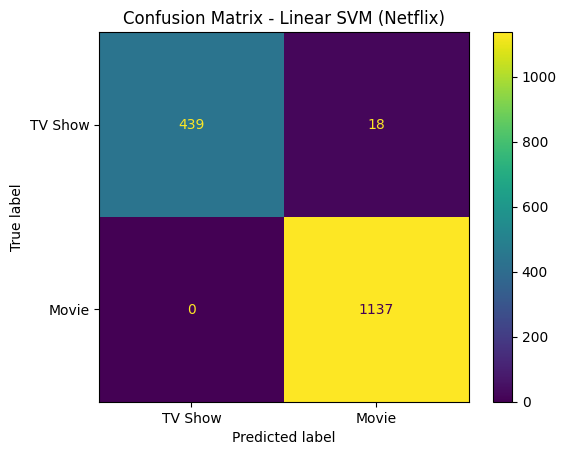

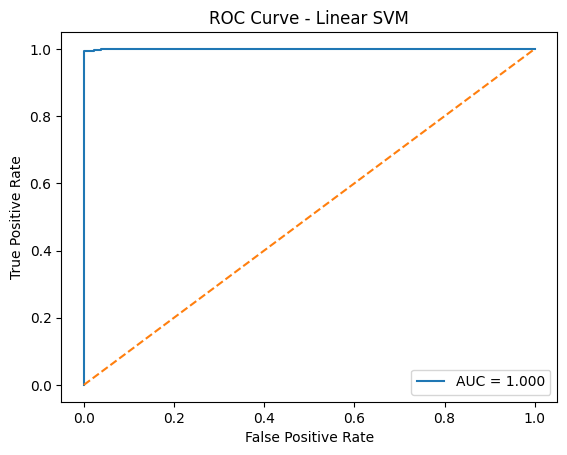

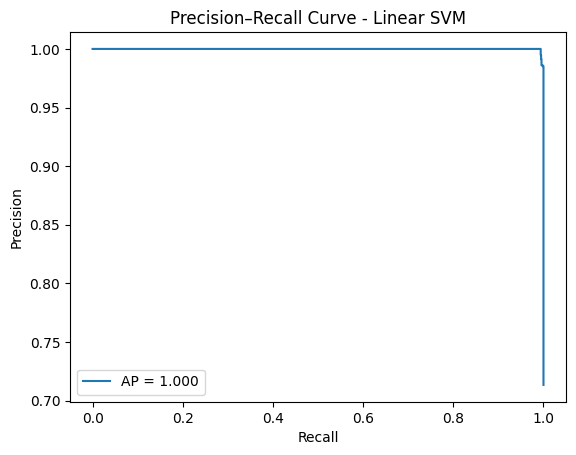

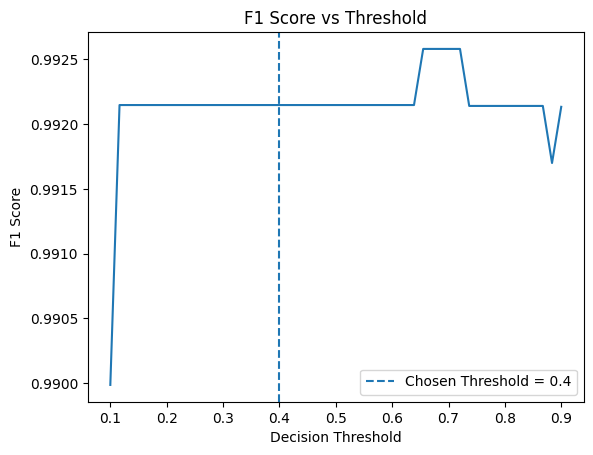

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

from scipy.stats import loguniform

# =============================
# LOAD NETFLIX DATASET
# =============================
df = pd.read_csv("netflix_titles.csv")

# =============================
# DATA CLEANING (NETFLIX VERSION)
# =============================
df = df[['type','release_year','rating','country','listed_in','duration']].copy()

# Convert duration text → numeric
df['duration_num'] = df['duration'].str.extract(r'(\d+)').astype(float)
df.drop('duration', axis=1, inplace=True)

df.dropna(inplace=True)

# Convert target into binary (same style as credit dataset)
df['type'] = df['type'].map({'Movie':1, 'TV Show':0})

# One-hot encode categorical features
df = pd.get_dummies(df, columns=['rating','country','listed_in'], drop_first=True)

# =============================
# FEATURES + TARGET
# =============================
X = df.drop('type', axis=1)
y = df['type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# =============================
# STANDARD SCALING
# =============================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =============================
# BASE LINEAR SVM
# =============================
base_svm = LinearSVC(
    class_weight='balanced',
    dual=False,
    max_iter=8000,
    random_state=42
)

param_dist = {
    'C': loguniform(1e-2, 10)
}

random_search = RandomizedSearchCV(
    estimator=base_svm,
    param_distributions=param_dist,
    n_iter=15,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

print("Tuning Linear SVM...")
random_search.fit(X_train_scaled, y_train)

print("\nBest Parameters:", random_search.best_params_)

# =============================
# CALIBRATED MODEL (FOR PROBABILITY)
# =============================
calibrated_svm = CalibratedClassifierCV(
    random_search.best_estimator_,
    method='sigmoid',
    cv=3
)

calibrated_svm.fit(X_train_scaled, y_train)

y_probs = calibrated_svm.predict_proba(X_test_scaled)[:,1]

threshold = 0.40
y_pred = (y_probs >= threshold).astype(int)

# =============================
# EVALUATION
# =============================
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

print("\n--- Accuracy ---")
print(f"{accuracy_score(y_test, y_pred):.4f}")

print("\n--- F1 Score ---")
print(f"{f1_score(y_test, y_pred):.4f}")

# =============================
# CONFUSION MATRIX GRAPH
# =============================
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['TV Show','Movie'])

disp.plot()
plt.title("Confusion Matrix - Linear SVM (Netflix)")
plt.show()

# =============================
# ROC CURVE
# =============================
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Linear SVM")
plt.legend()
plt.show()

# =============================
# PRECISION-RECALL CURVE
# =============================
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, y_probs)
avg_precision = average_precision_score(y_test, y_probs)

plt.figure()
plt.plot(recall, precision, label=f"AP = {avg_precision:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve - Linear SVM")
plt.legend()
plt.show()

# =============================
# THRESHOLD VS F1 GRAPH
# =============================
thresholds = np.linspace(0.1, 0.9, 50)
f1_scores = []

for t in thresholds:
    y_temp = (y_probs >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_temp))

plt.figure()
plt.plot(thresholds, f1_scores)
plt.axvline(x=threshold, linestyle='--',
            label=f"Chosen Threshold = {threshold}")
plt.xlabel("Decision Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Threshold")
plt.legend()
plt.show()
